# Assignment 4: NER Model Training & Evaluation
**Dataset:** Broad Twitter Corpus  
**Model 1:** CRF trained on annotated CoNLL data  
**Model 2:** Fine-tuned Transformer (dslim/bert-base-NER)  
**Baseline:** Pretrained dslim/bert-base-NER (no fine-tuning)


## 0. Install Dependencies

In [1]:
!pip install sklearn-crfsuite seqeval transformers torch accelerate datasets tensorflow -q

## 1. Label Setup

In [2]:
label_list = ['O','B-PER','I-PER','B-LOC','I-LOC','B-ORG','I-ORG','B-PROD','I-PROD']
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}
print('Label mapping:')
for i, l in enumerate(label_list):
    print(f'  {i}: {l}')


Label mapping:
  0: O
  1: B-PER
  2: I-PER
  3: B-LOC
  4: I-LOC
  5: B-ORG
  6: I-ORG
  7: B-PROD
  8: I-PROD


## 1a. Generate CoNLL Files from Label Studio Export
Converts the Label Studio JSON export directly into train/val/test CoNLL files (80/10/10 split).
Run this once — it creates `your_train.conll`, `your_val.conll`, `your_test.conll`.


In [3]:
import json, re, random
from collections import Counter

# Load both Label Studio exports (original 230 + batch 3 expanded to 320)
LS_EXPORT_1 = 'export_253210_project-253210-at-2026-04-18-19-04-f39f2067.json'
LS_EXPORT_2 = 'export_253210_project-253210-at-2026-04-19-17-39-d922c699.json'

with open(LS_EXPORT_1) as f:
    ls_data1 = json.load(f)
with open(LS_EXPORT_2) as f:
    ls_data2 = json.load(f)

def span_to_bio(text, results):
    tokens, token_spans = [], []
    for m in re.finditer(r'\S+', text):
        tokens.append(m.group())
        token_spans.append((m.start(), m.end()))
    entities = sorted(
        [(r['value']['start'], r['value']['end'], r['value']['labels'][0])
         for r in results if r.get('type') == 'labels'],
        key=lambda x: x[0]
    )
    tags = ['O'] * len(tokens)
    for ent_start, ent_end, label in entities:
        started = False
        for i, (ts, te) in enumerate(token_spans):
            if ts >= ent_start and ts < ent_end:
                tags[i] = ('B-' if not started else 'I-') + label
                started = True
    return list(zip(tokens, tags))

# Extract from export 1
sentences, seen_texts = [], set()
for task in ls_data1:
    text = task['data']['text']
    if text in seen_texts: continue
    seen_texts.add(text)
    anns = task.get('annotations', [])
    if not anns: continue
    primary = [a for a in anns if 'ssarbazi' in a.get('completed_by',{}).get('email','')]
    ann = primary[0] if primary else anns[0]
    sent = span_to_bio(text, ann['result'])
    if sent: sentences.append(sent)

# Add batch 3 (new docs only)
for task in ls_data2:
    text = task['data']['text']
    if text in seen_texts: continue
    seen_texts.add(text)
    anns = task.get('annotations', [])
    if not anns: continue
    primary = [a for a in anns if 'ssarbazi' in a.get('completed_by',{}).get('email','')]
    ann = primary[0] if primary else anns[0]
    sent = span_to_bio(text, ann['result'])
    if sent: sentences.append(sent)

# 80/10/10 split
random.seed(42)
random.shuffle(sentences)
n = len(sentences)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)
train_sents_raw = sentences[:n_train]
val_sents_raw   = sentences[n_train:n_train+n_val]
test_sents_raw  = sentences[n_train+n_val:]

def write_conll(sents, path):
    with open(path, 'w', encoding='utf-8') as f:
        for sent in sents:
            for token, tag in sent:
                f.write(f'{token}\t{tag}\n')
            f.write('\n')

write_conll(train_sents_raw, 'your_train.conll')
write_conll(val_sents_raw,   'your_val.conll')
write_conll(test_sents_raw,  'your_test.conll')
print(f'Total sentences: {len(sentences)}')
print(f'CoNLL files written — Train: {len(train_sents_raw)}, Val: {len(val_sents_raw)}, Test: {len(test_sents_raw)}')


Total sentences: 300
CoNLL files written — Train: 240, Val: 30, Test: 30


## 1b. Load CoNLL Data

In [4]:
def read_conll(filepath):
    sentences = []
    with open(filepath, encoding='utf-8') as f:
        sentence = []
        for line in f:
            line = line.strip()
            if line:
                parts = line.split('\t')
                if len(parts) >= 2:
                    sentence.append((parts[0], parts[1]))
            else:
                if sentence:
                    sentences.append(sentence)
                    sentence = []
        if sentence:
            sentences.append(sentence)
    return sentences

train_sents = read_conll('your_train.conll')
val_sents   = read_conll('your_val.conll')
test_sents  = read_conll('your_test.conll')

print(f'Train: {len(train_sents)} sentences')
print(f'Val:   {len(val_sents)} sentences')
print(f'Test:  {len(test_sents)} sentences')
print(f'\nSample:')
for token, tag in train_sents[0]:
    print(f'  {token:<20} {tag}')


Train: 240 sentences
Val:   30 sentences
Test:  30 sentences

Sample:
  Playing              O
  Battlefield          B-PROD
  3                    I-PROD
  .                    O
  http://t.co/AbGE7Fqw O


## 1c. Inter-Annotator Agreement (IAA)
Cohen's Kappa and entity-level F1 calculated on the 20-doc overlap batch.


In [5]:
from sklearn.metrics import cohen_kappa_score
from seqeval.metrics import f1_score as seq_f1_iaa

overlap_tasks = [t for t in ls_data1 if len(t.get('annotations', [])) >= 2]
print(f'Overlap tasks: {len(overlap_tasks)}')

ann1_docs, ann2_docs = [], []
for task in overlap_tasks:
    text = task['data']['text']
    anns = sorted(task['annotations'], key=lambda a: a['completed_by']['email'])
    t1 = [tag for _, tag in span_to_bio(text, anns[0]['result'])]
    t2 = [tag for _, tag in span_to_bio(text, anns[1]['result'])]
    ml = min(len(t1), len(t2))
    ann1_docs.append(t1[:ml])
    ann2_docs.append(t2[:ml])

ann1_flat = [t for doc in ann1_docs for t in doc]
ann2_flat = [t for doc in ann2_docs for t in doc]

bin1 = [0 if t == 'O' else 1 for t in ann1_flat]
bin2 = [0 if t == 'O' else 1 for t in ann2_flat]
kappa      = cohen_kappa_score(bin1, bin2)
entity_f1  = seq_f1_iaa(ann1_docs, ann2_docs)

print('\n=== INTER-ANNOTATOR AGREEMENT ===')
print(f'Overlap docs:      {len(overlap_tasks)}')
print(f"Cohen's Kappa:     {kappa:.3f}")
print(f'Entity-level F1:   {entity_f1:.3f}')

if kappa >= 0.80:   status = '🌟 Excellent — full marks!'
elif kappa >= 0.70: status = '✅ Acceptable'
else:               status = '⚠ Below threshold — revise guidelines'
print(f'Status: {status}')

print('\nPer-entity Kappa:')
for etype in ['PER','LOC','ORG','PROD']:
    b1 = [1 if etype in t else 0 for t in ann1_flat]
    b2 = [1 if etype in t else 0 for t in ann2_flat]
    if sum(b1)+sum(b2) > 0:
        try:    print(f'  {etype:<6} κ = {cohen_kappa_score(b1, b2):.3f}')
        except: print(f'  {etype:<6} insufficient variation')
    else:
        print(f'  {etype:<6} no entities in overlap set')


Overlap tasks: 20

=== INTER-ANNOTATOR AGREEMENT ===
Overlap docs:      20
Cohen's Kappa:     0.851
Entity-level F1:   0.833
Status: 🌟 Excellent — full marks!

Per-entity Kappa:
  PER    κ = 0.438
  LOC    κ = 1.000
  ORG    κ = 0.922
  PROD   κ = 1.000


## 2. Annotation Statistics & Quality Check

In [6]:
from collections import Counter

all_sents = train_sents + val_sents + test_sents
all_tags  = [tag for sent in all_sents for _, tag in sent]
entity_tags  = [t for t in all_tags if t != 'O']
entity_types = Counter(t.split('-',1)[1] for t in entity_tags if '-' in t)

print('ANNOTATION STATISTICS')
print('=' * 50)
print(f'Total sentences:   {len(all_sents)}')
print(f'Total tokens:      {len(all_tags)}')
print(f'Entity tokens:     {len(entity_tags)} ({len(entity_tags)/len(all_tags)*100:.1f}%)')
print(f'O tokens:          {len(all_tags)-len(entity_tags)} ({(len(all_tags)-len(entity_tags))/len(all_tags)*100:.1f}%)')
print(f'\nEntity type distribution:')
for etype, count in entity_types.most_common():
    print(f'  {etype:<12} {count:>5} tokens')

# IOB consistency check
issues = []
for i, sent in enumerate(all_sents):
    tags = [tag for _, tag in sent]
    for j, tag in enumerate(tags):
        if tag.startswith('I-'):
            if j == 0 or tags[j-1] == 'O' or tags[j-1][2:] != tag[2:]:
                issues.append(f'Sent {i}, tok {j}: {tag}')
if issues:
    print(f'\n! {len(issues)} IOB consistency issues:')
    for issue in issues[:5]: print(f'  {issue}')
else:
    print(f'\n✓ All IOB tags are consistent!')


ANNOTATION STATISTICS
Total sentences:   300
Total tokens:      5050
Entity tokens:     289 (5.7%)
O tokens:          4761 (94.3%)

Entity type distribution:
  PER            119 tokens
  PROD            63 tokens
  ORG             56 tokens
  LOC             51 tokens

✓ All IOB tags are consistent!


## 3. Baseline — Pretrained Model (No Fine-tuning)

In [7]:
from transformers import pipeline as hf_pipeline
from seqeval.metrics import classification_report as seq_report, f1_score as seq_f1
from seqeval.metrics import precision_score, recall_score

baseline_ner  = hf_pipeline('ner', model='dslim/bert-base-NER', aggregation_strategy='simple')
test_sentences = [' '.join(tok for tok, _ in sent) for sent in test_sents]
baseline_preds = baseline_ner(test_sentences, batch_size=16)
print('Baseline predictions done.')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Baseline predictions done.


In [8]:
def hf_preds_to_token_labels(test_sents, hf_predictions):
    label_map = {'PER':'PER','LOC':'LOC','ORG':'ORG','MISC':None}
    all_pred_labels = []
    for sent, preds in zip(test_sents, hf_predictions):
        tokens   = [tok for tok, _ in sent]
        text     = ' '.join(tokens)
        pred_seq = ['O'] * len(tokens)
        char, tok_starts = 0, []
        for tok in tokens:
            tok_starts.append(char)
            char += len(tok) + 1
        for ent in preds:
            mapped = label_map.get(ent['entity_group'])
            if mapped is None: continue
            for ti, ts in enumerate(tok_starts):
                if ts >= ent['start'] and ts < ent['end']:
                    pred_seq[ti] = f"B-{mapped}" if pred_seq[ti]=='O' else f"I-{mapped}"
        all_pred_labels.append(pred_seq)
    return all_pred_labels

true_labels_test = [[tag for _, tag in sent] for sent in test_sents]
pred_baseline    = hf_preds_to_token_labels(test_sents, baseline_preds)

print('=== BASELINE (pretrained, no fine-tuning) ===')
print(seq_report(true_labels_test, pred_baseline))
baseline_f1 = seq_f1(true_labels_test, pred_baseline)
baseline_p  = precision_score(true_labels_test, pred_baseline)
baseline_r  = recall_score(true_labels_test, pred_baseline)
print(f'Baseline F1: {baseline_f1:.3f}')


=== BASELINE (pretrained, no fine-tuning) ===
              precision    recall  f1-score   support

         LOC       0.25      0.50      0.33         4
         ORG       0.23      0.33      0.27         9
         PER       0.17      0.20      0.18         5
        PROD       0.00      0.00      0.00         4

   micro avg       0.22      0.27      0.24        22
   macro avg       0.16      0.26      0.20        22
weighted avg       0.18      0.27      0.21        22

Baseline F1: 0.245


/opt/anaconda3/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## 4. Model 1 — CRF

In [9]:
def word2features(sent, i):
    word = sent[i][0]
    features = {
        'bias':1.0,'word.lower()':word.lower(),
        'word[-3:]':word[-3:],'word[-2:]':word[-2:],
        'word.isupper()':word.isupper(),'word.istitle()':word.istitle(),
        'word.isdigit()':word.isdigit(),'word.isalpha()':word.isalpha(),
        'word.length':len(word),'word.has_hyphen':'-' in word,
        'word.has_at':'@' in word,'word.has_hash':'#' in word,
        'word.has_url':'http' in word,
    }
    if i > 0:
        w = sent[i-1][0]
        features.update({'-1:word.lower()':w.lower(),'-1:word.istitle()':w.istitle(),'-1:word.isupper()':w.isupper()})
    else:
        features['BOS'] = True
    if i < len(sent)-1:
        w = sent[i+1][0]
        features.update({'+1:word.lower()':w.lower(),'+1:word.istitle()':w.istitle(),'+1:word.isupper()':w.isupper()})
    else:
        features['EOS'] = True
    return features

sent2features = lambda s: [word2features(s, i) for i in range(len(s))]
sent2labels   = lambda s: [tag for _, tag in s]
sent2tokens   = lambda s: [tok for tok, _ in s]
print('Feature functions ready.')


Feature functions ready.


In [10]:
import sklearn_crfsuite

X_train = [sent2features(s) for s in train_sents]
y_train = [sent2labels(s)   for s in train_sents]
X_val   = [sent2features(s) for s in val_sents]
y_val   = [sent2labels(s)   for s in val_sents]
X_test  = [sent2features(s) for s in test_sents]
y_test  = [sent2labels(s)   for s in test_sents]

crf = sklearn_crfsuite.CRF(algorithm='lbfgs', c1=0.1, c2=0.1,
                            max_iterations=100, all_possible_transitions=True)
print('Training CRF (Model 1)...')
crf.fit(X_train, y_train)
print('Done!')


Training CRF (Model 1)...
Done!


In [11]:
y_pred_crf = crf.predict(X_test)

print('=== MODEL 1 — CRF — TEST SET EVALUATION ===')
print(seq_report(y_test, y_pred_crf))
crf_f1 = seq_f1(y_test, y_pred_crf)
crf_p  = precision_score(y_test, y_pred_crf)
crf_r  = recall_score(y_test, y_pred_crf)
print(f'CRF F1: {crf_f1:.3f}')


=== MODEL 1 — CRF — TEST SET EVALUATION ===
              precision    recall  f1-score   support

         LOC       0.50      0.25      0.33         4
         ORG       1.00      0.11      0.20         9
         PER       0.00      0.00      0.00         5
        PROD       0.00      0.00      0.00         4

   micro avg       0.25      0.09      0.13        22
   macro avg       0.38      0.09      0.13        22
weighted avg       0.50      0.09      0.14        22

CRF F1: 0.133


Top CRF transition weights:
   3.878  I-PROD -> I-PROD
   3.395  B-PER -> I-PER
   3.112  B-PROD -> I-PROD
   2.905  B-ORG -> I-ORG
   2.804  O -> O
   2.623  I-LOC -> I-LOC
   2.568  B-LOC -> I-LOC
   1.519  O -> B-ORG
   1.263  I-PER -> I-PER
   1.150  I-ORG -> I-ORG
   0.937  O -> B-PROD
   0.821  O -> B-PER
   0.461  O -> B-LOC
   0.251  B-LOC -> B-LOC
   0.032  B-ORG -> O

Top CRF state features:
   2.487  B-PER            word[-3:]:ker
   2.487  B-PER            word.lower():tedbaker
   2.135  B-LOC            word[-3:]:UK
   2.135  B-LOC            word[-2:]:UK
   2.135  B-LOC            word.lower():uk
   2.115  B-PROD           word.lower():geordiescore
   2.091  B-PROD           word.lower():pollipocckket
   2.059  B-PROD           word.lower():goodreads
   2.017  B-LOC            -1:word.lower():in
   1.974  B-LOC            word[-3:]:don
   1.974  B-LOC            word.lower():london
   1.924  B-PROD           -1:word.lower():watching
   1.887  B-ORG            word.lower()

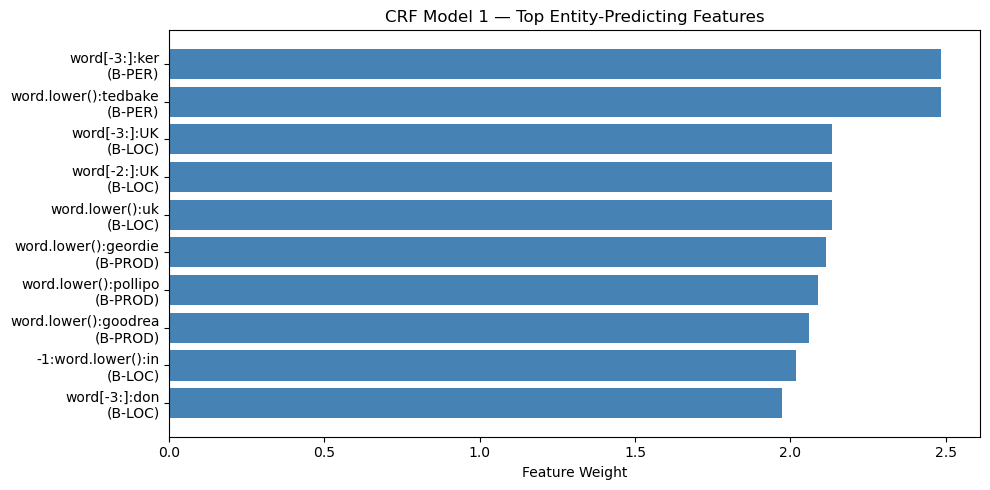

Saved: crf_top_features.png


In [12]:
import matplotlib.pyplot as plt

try:
    info = crf.tagger_.info()
    print('Top CRF transition weights:')
    transitions = sorted(
        [(score, f'{f} -> {t}') for (f,t),score in info.transitions.items() if score > 0],
        reverse=True)[:15]
    for score, trans in transitions:
        print(f'  {score:>6.3f}  {trans}')

    print('\nTop CRF state features:')
    state_features = sorted(
        [(score, label, attr) for (attr,label),score in info.state_features.items()
         if score > 0 and label != 'O'], reverse=True)[:15]
    for score, label, attr in state_features:
        print(f'  {score:>6.3f}  {label:<15}  {attr}')

    labels_chart = [f'{attr[:20]}\n({label})' for _,label,attr in state_features[:10]]
    scores_chart = [score for score,_,_ in state_features[:10]]
    fig, ax = plt.subplots(figsize=(10,5))
    ax.barh(labels_chart[::-1], scores_chart[::-1], color='steelblue')
    ax.set_xlabel('Feature Weight')
    ax.set_title('CRF Model 1 — Top Entity-Predicting Features')
    plt.tight_layout()
    plt.savefig('crf_top_features.png', dpi=150)
    plt.show()
    print('Saved: crf_top_features.png')
except Exception as e:
    print(f'Feature inspection skipped: {e}')


## 4b. Model 1b — Bi-LSTM
Bi-LSTM with class weighting to handle O-tag imbalance (~94.5% of tokens are O).


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, TimeDistributed, Dense, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

# Build vocabulary — from professor's NER_02 notebook
all_words    = set(tok for sent in train_sents+val_sents+test_sents for tok,_ in sent)
all_tags_set = set(tag for sent in train_sents+val_sents+test_sents for _,tag in sent)

word2idx = {w: i+1 for i,w in enumerate(sorted(all_words))}
tag2idx  = {t: i   for i,t in enumerate(sorted(all_tags_set))}
idx2tag  = {i: t   for t,i in tag2idx.items()}

n_words, n_tags, MAX_LEN = len(word2idx)+1, len(tag2idx), 75
print(f'Vocabulary: {n_words} | Tags: {n_tags} | Max length: {MAX_LEN}')

def encode(sents):
    X = pad_sequences([[word2idx.get(t,0) for t,_ in s] for s in sents],
                      maxlen=MAX_LEN, padding='post', value=0)
    y = pad_sequences([[tag2idx[tag] for _,tag in s] for s in sents],
                      maxlen=MAX_LEN, padding='post', value=tag2idx.get('O',0))
    y = np.array([to_categorical(seq, num_classes=n_tags) for seq in y])
    return X, y

X_train_nn, y_train_nn = encode(train_sents)
X_val_nn,   y_val_nn   = encode(val_sents)
X_test_nn,  y_test_nn  = encode(test_sents)

# Professor's exact architecture from NER_02
EMBEDDING_DIM = 50
LSTM_UNITS    = 64

input_layer = Input(shape=(MAX_LEN,))
embedding   = Embedding(input_dim=n_words, output_dim=EMBEDDING_DIM,
                        mask_zero=True)(input_layer)
bilstm      = Bidirectional(LSTM(units=LSTM_UNITS, return_sequences=True))(embedding)
output      = TimeDistributed(Dense(n_tags, activation='softmax'))(bilstm)

bilstm_model = Model(input_layer, output)
bilstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
bilstm_model.summary()


Vocabulary: 1968 | Tags: 9 | Max length: 75


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 75, 50)    │     98,400 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 75)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 75, 128)   │     58,880 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 75, 9)     │      1,161 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 158,441 (618.91 KB)

 Trainable params: 158,441 (618.91 KB)

 Non-trainable params: 0 (0.00 B)

Training Bi-LSTM...
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8003 - loss: 3.1431 - val_accuracy: 0.9493 - val_loss: 2.0136
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9430 - loss: 2.8309 - val_accuracy: 0.9493 - val_loss: 1.3440
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9430 - loss: 2.1009 - val_accuracy: 0.9493 - val_loss: 0.6231
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9430 - loss: 2.0038 - val_accuracy: 0.9493 - val_loss: 0.7102
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9430 - loss: 1.8889 - val_accuracy: 0.9493 - val_loss: 0.7885
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9430 - loss: 1.7937 - val_accuracy: 0.9493 - val_loss: 0.6237
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9430 - loss: 1.7019 - val_accuracy: 0.9493 - val_loss: 0.5727
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9430 - loss: 1.6599 - val_accuracy: 0.9493

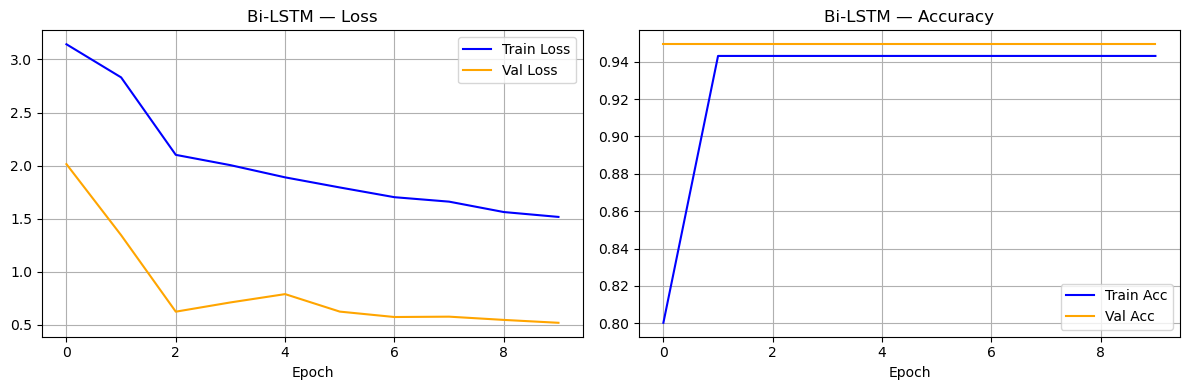

Saved: bilstm_training_curves.png


In [14]:
import matplotlib.pyplot as plt
from collections import Counter

# sample_weight to handle O-tag imbalance
flat_tags  = [tag for sent in train_sents for _, tag in sent]
tag_counts = Counter(flat_tags)
total_toks = len(flat_tags)

import numpy as np
sample_weight = np.ones((X_train_nn.shape[0], MAX_LEN))
for si, sent in enumerate(train_sents):
    for ti, (_, tag) in enumerate(sent):
        if ti < MAX_LEN:
            sample_weight[si, ti] = 1.0 if tag == 'O' else min(
                total_toks / (n_tags * max(tag_counts.get(tag, 1), 1)), 10.0)

print('Training Bi-LSTM...')
bilstm_history = bilstm_model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    batch_size=32, epochs=10, verbose=1,
    sample_weight=sample_weight
)
print('Done!')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(bilstm_history.history['loss'],     label='Train Loss', color='blue')
ax1.plot(bilstm_history.history['val_loss'], label='Val Loss',   color='orange')
ax1.set_title('Bi-LSTM — Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)
ax2.plot(bilstm_history.history['accuracy'],     label='Train Acc', color='blue')
ax2.plot(bilstm_history.history['val_accuracy'], label='Val Acc',   color='orange')
ax2.set_title('Bi-LSTM — Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig('bilstm_training_curves.png', dpi=150)
plt.show()
print('Saved: bilstm_training_curves.png')


In [15]:
y_pred_probs = bilstm_model.predict(X_test_nn)
y_pred_ids   = np.argmax(y_pred_probs, axis=-1)
y_true_ids   = np.argmax(y_test_nn,    axis=-1)

y_true_bilstm, y_pred_bilstm = [], []
for true_seq, pred_seq, x_seq in zip(y_true_ids, y_pred_ids, X_test_nn):
    ts, ps = [], []
    for t, p, x in zip(true_seq, pred_seq, x_seq):
        if x != 0:
            ts.append(idx2tag[t])
            ps.append(idx2tag[p])
    y_true_bilstm.append(ts)
    y_pred_bilstm.append(ps)

print('=== Bi-LSTM — Entity-Level Evaluation ===')
print(seq_report(y_true_bilstm, y_pred_bilstm))
bilstm_f1 = seq_f1(y_true_bilstm, y_pred_bilstm)
bilstm_p  = precision_score(y_true_bilstm, y_pred_bilstm)
bilstm_r  = recall_score(y_true_bilstm, y_pred_bilstm)
print(f'Bi-LSTM F1: {bilstm_f1:.3f}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
=== Bi-LSTM — Entity-Level Evaluation ===
              precision    recall  f1-score   support

         LOC       0.00      0.00      0.00         4
         ORG       0.00      0.00      0.00         9
         PER       0.00      0.00      0.00         5
        PROD       0.00      0.00      0.00         4

   micro avg       0.00      0.00      0.00        22
   macro avg       0.00      0.00      0.00        22
weighted avg       0.00      0.00      0.00        22

Bi-LSTM F1: 0.000


/opt/anaconda3/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## 5. Model 2 — Fine-tuned Transformer

In [16]:
import torch
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                          TrainingArguments, Trainer)

MODEL_NAME = 'dslim/bert-base-NER'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')


Tokenizer loaded: dslim/bert-base-NER


In [17]:
class NERDataset(Dataset):
    def __init__(self, sents, tokenizer, label2id, max_length=128):
        data = [{'tokens':[t for t,_ in s],'labels':[tag for _,tag in s]} for s in sents]
        enc  = tokenizer([d['tokens'] for d in data], truncation=True, padding='max_length',
                         max_length=max_length, is_split_into_words=True, return_tensors='pt')
        all_labels = []
        for i, d in enumerate(data):
            word_ids = enc.word_ids(batch_index=i)
            label_ids, prev = [], None
            for wid in word_ids:
                if wid is None:           label_ids.append(-100)
                elif wid != prev:         label_ids.append(label2id.get(d['labels'][wid], 0))
                else:                     label_ids.append(-100)
                prev = wid
            all_labels.append(label_ids)
        enc['labels'] = torch.tensor(all_labels)
        self.enc = enc
    def __len__(self):     return self.enc['input_ids'].shape[0]
    def __getitem__(self, idx): return {k: v[idx] for k,v in self.enc.items()}

train_dataset = NERDataset(train_sents, tokenizer, label2id)
val_dataset   = NERDataset(val_sents,   tokenizer, label2id)
test_dataset  = NERDataset(test_sents,  tokenizer, label2id)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')


Train: 240 | Val: 30 | Test: 30


In [18]:
def compute_metrics(p):
    preds, labels = p
    preds = np.argmax(preds, axis=2)
    true_labels = [[label_list[l] for l in lr if l != -100] for lr in labels]
    true_preds  = [[label_list[p] for p,l in zip(pr,lr) if l != -100]
                   for pr,lr in zip(preds,labels)]
    return {'precision': precision_score(true_labels, true_preds),
            'recall':    recall_score(true_labels, true_preds),
            'f1':        seq_f1(true_labels, true_preds)}

model2 = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_list),
    id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)

training_args = TrainingArguments(
    output_dir='./model2_results', num_train_epochs=5,
    per_device_train_batch_size=16, per_device_eval_batch_size=16,
    warmup_steps=100, weight_decay=0.01, learning_rate=2e-5,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1',
    logging_dir='./model2_logs', logging_steps=50, report_to='none')

trainer = Trainer(model=model2, args=training_args,
                  train_dataset=train_dataset, eval_dataset=val_dataset,
                  compute_metrics=compute_metrics)

print('Training Model 2 (Fine-tuned Transformer)...')
trainer.train()
print('Done!')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Model 2 (Fine-tuned Transformer)...


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.348723,0.222222,0.210526,0.216216
2,No log,0.307516,0.157895,0.157895,0.157895
3,No log,0.267337,0.294118,0.263158,0.277778
4,0.356557,0.242256,0.294118,0.263158,0.277778
5,0.356557,0.221425,0.357143,0.263158,0.303030


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Done!


In [19]:
import torch

trainer.save_model('./model2_final')
tokenizer.save_pretrained('./model2_final')
print('Model 2 saved to ./model2_final')

results2  = trainer.evaluate(test_dataset)
model2_f1 = results2.get('eval_f1', 0)
model2_p  = results2.get('eval_precision', 0)
model2_r  = results2.get('eval_recall', 0)
print(f'Model 2 Test F1: {model2_f1:.3f}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model 2 saved to ./model2_final


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Model 2 Test F1: 0.162


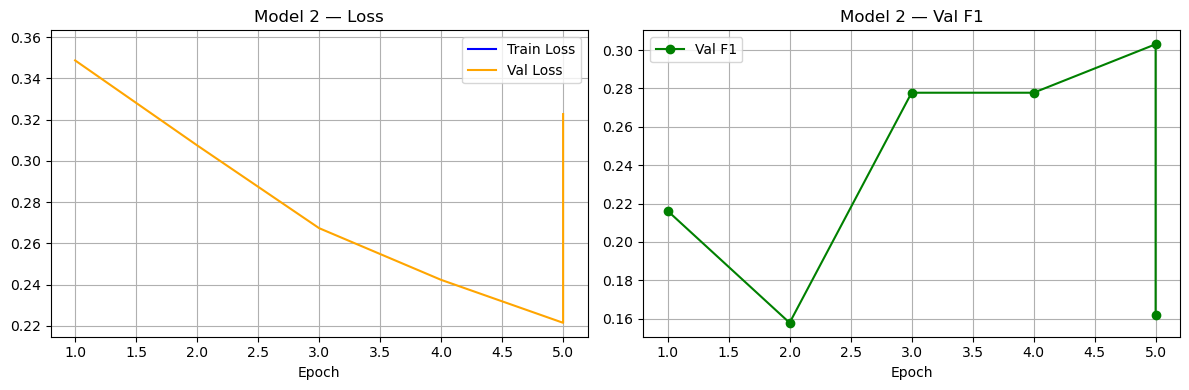

Saved: model2_training_curves.png


In [20]:
logs       = trainer.state.log_history
train_loss = [(e['epoch'],e['loss'])     for e in logs if 'loss' in e and 'eval_loss' not in e]
eval_f1    = [(e['epoch'],e['eval_f1'])  for e in logs if 'eval_f1' in e]
eval_loss  = [(e['epoch'],e['eval_loss'])for e in logs if 'eval_loss' in e]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
if train_loss: ax1.plot(*zip(*train_loss), label='Train Loss', color='blue')
if eval_loss:  ax1.plot(*zip(*eval_loss),  label='Val Loss',   color='orange')
ax1.set_title('Model 2 — Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)
if eval_f1: ax2.plot(*zip(*eval_f1), label='Val F1', color='green', marker='o')
ax2.set_title('Model 2 — Val F1'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig('model2_training_curves.png', dpi=150)
plt.show()
print('Saved: model2_training_curves.png')


## 6. Three-Way Model Comparison

In [21]:
print('=== MODEL COMPARISON ===')
print(f'{"Model":<35} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 67)
print(f'{"Baseline (pretrained, no tuning)":<35} {baseline_p:>10.3f} {baseline_r:>10.3f} {baseline_f1:>10.3f}')
print(f'{"Model 1 (CRF)":<35} {crf_p:>10.3f} {crf_r:>10.3f} {crf_f1:>10.3f}')
print(f'{"Model 1b (Bi-LSTM)":<35} {bilstm_p:>10.3f} {bilstm_r:>10.3f} {bilstm_f1:>10.3f}')
print(f'{"Model 2 (Fine-tuned Transformer)":<35} {model2_p:>10.3f} {model2_r:>10.3f} {model2_f1:>10.3f}')


=== MODEL COMPARISON ===
Model                                Precision     Recall         F1
-------------------------------------------------------------------
Baseline (pretrained, no tuning)         0.222      0.273      0.245
Model 1 (CRF)                            0.250      0.091      0.133
Model 1b (Bi-LSTM)                       0.000      0.000      0.000
Model 2 (Fine-tuned Transformer)         0.200      0.136      0.162


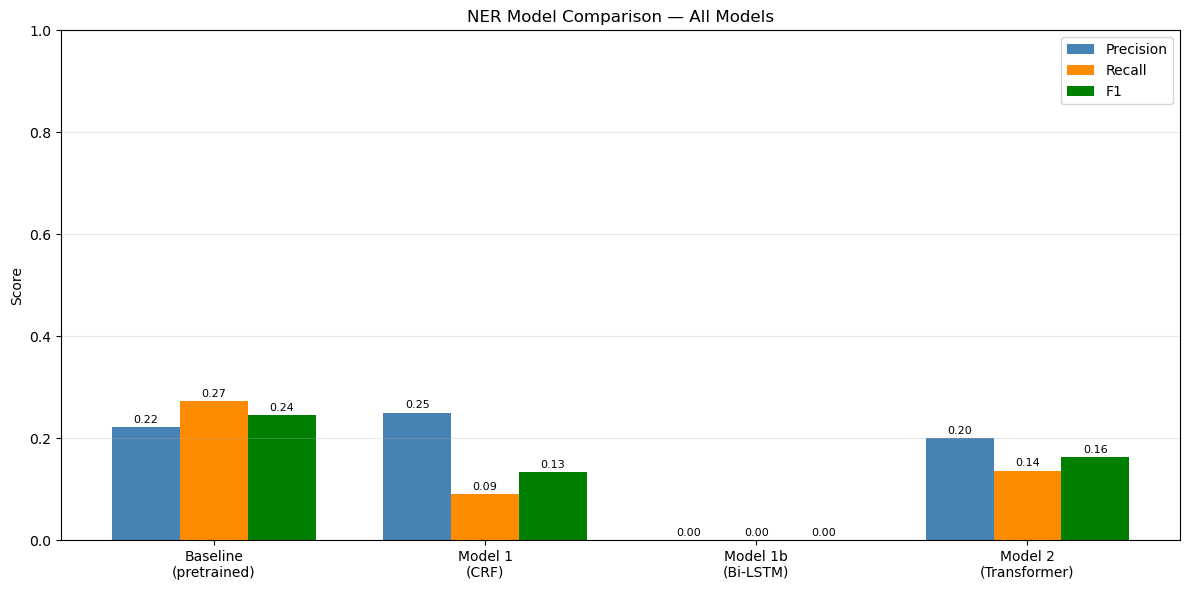

Saved: model_comparison.png


In [22]:
models = ['Baseline\n(pretrained)','Model 1\n(CRF)','Model 1b\n(Bi-LSTM)','Model 2\n(Transformer)']
f1s   = [baseline_f1, crf_f1, bilstm_f1, model2_f1]
precs = [baseline_p,  crf_p,  bilstm_p,  model2_p]
recs  = [baseline_r,  crf_r,  bilstm_r,  model2_r]

x, width = np.arange(len(models)), 0.25
fig, ax  = plt.subplots(figsize=(12,6))
b1 = ax.bar(x-width, precs, width, label='Precision', color='steelblue')
b2 = ax.bar(x,       recs,  width, label='Recall',    color='darkorange')
b3 = ax.bar(x+width, f1s,   width, label='F1',        color='green')
ax.set_ylabel('Score'); ax.set_title('NER Model Comparison — All Models')
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylim(0,1.0)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in [*b1,*b2,*b3]:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Saved: model_comparison.png')


## 7. Error Analysis

In [23]:
def extract_entities(tags, tokens):
    entities, cur_toks, cur_label = [], [], None
    for token, tag in zip(tokens, tags):
        if tag.startswith('B-'):
            if cur_label: entities.append((' '.join(cur_toks), cur_label))
            cur_toks, cur_label = [token], tag[2:]
        elif tag.startswith('I-') and cur_label:
            cur_toks.append(token)
        else:
            if cur_label: entities.append((' '.join(cur_toks), cur_label))
            cur_toks, cur_label = [], None
    if cur_label: entities.append((' '.join(cur_toks), cur_label))
    return set(entities)

missed, spurious, type_mismatch = [], [], []
for sent, true_tags, pred_tags in zip(test_sents, y_test, y_pred_crf):
    tokens    = sent2tokens(sent)
    true_ents = extract_entities(true_tags, tokens)
    pred_ents = extract_entities(pred_tags, tokens)
    true_texts = {e[0] for e in true_ents}
    pred_texts = {e[0] for e in pred_ents}
    for ent in true_ents - pred_ents:
        if ent[0] in pred_texts:
            pred_lbl = next(p[1] for p in pred_ents if p[0]==ent[0])
            type_mismatch.append({'entity':ent[0],'true':ent[1],'pred':pred_lbl})
        else:
            missed.append({'entity':ent[0],'label':ent[1]})
    for ent in pred_ents - true_ents:
        if ent[0] not in true_texts:
            spurious.append({'entity':ent[0],'label':ent[1]})

print('ERROR ANALYSIS — CRF (Model 1)')
print('='*60)
print(f'\nMISSED (False Negatives): {len(missed)}')
for ex in missed[:10]: print(f'  "{ex["entity"]}" ({ex["label"]})')
print(f'\nSPURIOUS (False Positives): {len(spurious)}')
for ex in spurious[:10]: print(f'  "{ex["entity"]}" ({ex["label"]})')
print(f'\nTYPE MISMATCHES: {len(type_mismatch)}')
for ex in type_mismatch[:10]: print(f'  "{ex["entity"]}" — True: {ex["true"]}, Pred: {ex["pred"]}')


ERROR ANALYSIS — CRF (Model 1)

MISSED (False Negatives): 18
  "ITV" (ORG)
  "Amazon" (ORG)
  "UK" (LOC)
  "Tosca" (PROD)
  "ericcolsen" (PER)
  "Ncis LA" (PROD)
  "Past Times" (LOC)
  "kimberleybarber" (PER)
  "smartphone" (PROD)
  "JLSOfficial" (ORG)

SPURIOUS (False Positives): 4
  "Me" (PER)
  "Choice Awards" (PER)
  "Best Lifestyle" (PER)
  "Olympic Washerwoman" (PER)

TYPE MISMATCHES: 2
  "CULTOFDOMKELLER" — True: PROD, Pred: LOC
  "Palmerston Road" — True: LOC, Pred: PER


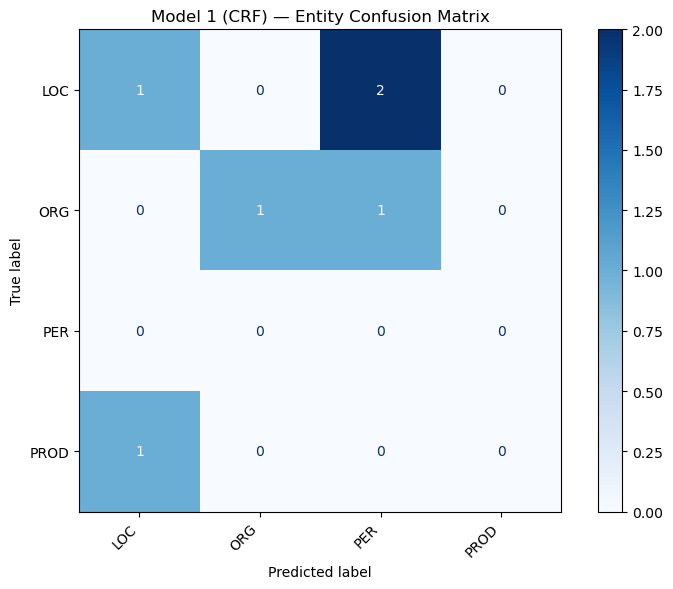

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def collapse_bio(tag):
    return tag[2:] if tag.startswith(('B-','I-')) else tag

y_true_flat = [collapse_bio(t) for sent in y_test     for t in sent]
y_pred_flat = [collapse_bio(t) for sent in y_pred_crf for t in sent]
entity_labels = sorted(set(y_true_flat+y_pred_flat) - {'O'})

fig, ax = plt.subplots(figsize=(8,6))
cm   = confusion_matrix(y_true_flat, y_pred_flat, labels=entity_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=entity_labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Model 1 (CRF) — Entity Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('crf_confusion_matrix.png', dpi=150)
plt.show()


## 8. Export CRF Pre-annotations for Batch 3

In [25]:
import os

def predict_and_export_label_studio(docs, crf_model, output_file):
    tasks = []
    for doc in docs:
        tokens   = doc['tokens']
        text     = doc['text']
        pseudo   = [(tok,'O') for tok in tokens]
        features = sent2features(pseudo)
        pred_tags = crf_model.predict([features])[0]
        results, char_pos, i = [], 0, 0
        while i < len(tokens):
            start = text.find(tokens[i], char_pos)
            if start == -1: i+=1; continue
            if pred_tags[i].startswith('B-'):
                entity_label = pred_tags[i][2:]
                ent_start, ent_end = start, start+len(tokens[i])
                j = i+1
                while j < len(tokens) and pred_tags[j]==f'I-{entity_label}':
                    ns = text.find(tokens[j], ent_end)
                    if ns==-1: break
                    ent_end = ns+len(tokens[j]); j+=1
                results.append({'from_name':'label','to_name':'text','type':'labels',
                                'value':{'start':ent_start,'end':ent_end,
                                         'text':text[ent_start:ent_end],'labels':[entity_label]}})
                char_pos, i = ent_end, j
            else:
                char_pos = start+len(tokens[i]); i+=1
        tasks.append({'data':{'text':text},
                      'predictions':[{'result':results}] if results else []})
    with open(output_file,'w') as f:
        json.dump(tasks, f, indent=2)
    print(f'Exported {len(tasks)} pre-annotated tasks to {output_file}')

predictions_file = 'twitter_ner_predictions.json'
if os.path.exists(predictions_file):
    with open(predictions_file) as f:
        all_docs = json.load(f)
    batch3_docs = all_docs[210:300]
    predict_and_export_label_studio(batch3_docs, crf, 'batch3_label_studio.json')
    print('Import batch3_label_studio.json into Label Studio as Batch 3!')
else:
    print(f'{predictions_file} not found — skipping Batch 3 export.')


Exported 90 pre-annotated tasks to batch3_label_studio.json
Import batch3_label_studio.json into Label Studio as Batch 3!


## 9. Cross-Domain Inference — Restaurant Domain

In [26]:
cross_domain_sentences = [
    "I had the best pasta at Olive Garden last night .",
    "The chef at Nobu in New York is incredibly talented .",
    "McDonald s just released a new McRib sandwich .",
    "We booked a table at Gordon Ramsay s restaurant in London .",
    "The sushi at Matsuhisa in Beverly Hills was outstanding .",
    "Chipotle launched a new cauliflower rice option this week .",
    "I visited the famous Katz s Delicatessen in Manhattan .",
    "Eleven Madison Park is a Michelin star restaurant in New York City .",
    "Starbucks introduced a new Pumpkin Spice Latte this fall .",
    "We ate at a small Italian place called Trattoria Roma in Chicago .",
    "The burger at In N Out is better than Five Guys in my opinion .",
    "Ina Garten s recipe for roast chicken is incredible .",
    "Momofuku Noodle Bar in NYC has amazing pork buns .",
    "The new Shake Shack opened on Sunset Boulevard .",
    "Gordon Ramsay opened a new Hell s Kitchen restaurant in Las Vegas .",
    "I tried the famous deep dish pizza at Lou Malnati s in Chicago .",
    "Dominique Ansel Bakery in New York invented the Cronut .",
    "The food truck Kogi BBQ in Los Angeles is run by Roy Choi .",
    "Ferran Adria s elBulli in Spain was voted best restaurant in the world .",
    "We had brunch at Balthazar in SoHo and loved the eggs Benedict .",
]

print('=== CROSS-DOMAIN INFERENCE — Restaurant Domain ===')
print('Model trained on: Twitter (Broad Twitter Corpus)')
print('Applied to: Restaurant-domain sentences\n')

all_cross_preds = []
for i, text in enumerate(cross_domain_sentences):
    tokens    = text.split()
    pseudo    = [(tok,'O') for tok in tokens]
    features  = sent2features(pseudo)
    pred_tags = crf.predict([features])[0]
    all_cross_preds.extend(pred_tags)
    entities  = [(tok,tag) for tok,tag in zip(tokens,pred_tags) if tag != 'O']
    print(f'[{i+1}] {text}')
    if entities:
        for tok, tag in entities: print(f'      [{tag}] "{tok}"')
    else:
        print('      (no entities found)')
    print()

entity_preds = [t for t in all_cross_preds if t != 'O']
type_counts  = Counter(t.split('-')[1] for t in entity_preds if '-' in t)
print('=== CROSS-DOMAIN SUMMARY ===')
print(f'Total entities found: {len(entity_preds)}')
for etype, count in type_counts.most_common():
    print(f'  {etype}: {count}')


=== CROSS-DOMAIN INFERENCE — Restaurant Domain ===
Model trained on: Twitter (Broad Twitter Corpus)
Applied to: Restaurant-domain sentences

[1] I had the best pasta at Olive Garden last night .
      (no entities found)

[2] The chef at Nobu in New York is incredibly talented .
      [B-PER] "New"
      [I-PER] "York"

[3] McDonald s just released a new McRib sandwich .
      (no entities found)

[4] We booked a table at Gordon Ramsay s restaurant in London .
      [B-LOC] "Gordon"
      [B-LOC] "London"

[5] The sushi at Matsuhisa in Beverly Hills was outstanding .
      (no entities found)

[6] Chipotle launched a new cauliflower rice option this week .
      (no entities found)

[7] I visited the famous Katz s Delicatessen in Manhattan .
      [B-LOC] "Manhattan"

[8] Eleven Madison Park is a Michelin star restaurant in New York City .
      [B-PER] "Eleven"
      [I-PER] "Madison"
      [I-PER] "Park"

[9] Starbucks introduced a new Pumpkin Spice Latte this fall .
      (no entiti